In [1]:
import pandas as pd
import numpy as np
import re
import os
import warnings
import itertools
from pathlib import Path
from collections import Counter
warnings.filterwarnings('ignore')

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.util import ngrams
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

EMO_COLORS = {'Happy': '#2ECC71', 'Love': '#E91E63', 'Sadness': '#3498DB',
              'Fear': '#F39C12', 'Anger': '#E74C3C'}
SENT_COLORS = {'Positive': '#2ECC71', 'Negative': '#E74C3C'}
EMO_ORDER = ['Anger', 'Fear', 'Sadness', 'Love', 'Happy']
RANDOM_STATE = 42

# 1. Dataset Overview

In [2]:
df_path = Path("../data/raw/ecommerce_reviews.csv")

if not os.path.exists(df_path):
    df = pd.read_csv("https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/59cda965-7204-45c5-b4ca-29dc27392cf7")
    df_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(df_path, index=False)
else:
    df = pd.read_csv(df_path)

df["text"] = df["Customer Review"].copy()
df["text-original"] = df["Customer Review"].copy()

print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nSentiment distribution:\n{df['Sentiment'].value_counts()}")
print(f"\nEmotion distribution:\n{df['Emotion'].value_counts()}")

Total rows: 5400
Columns: ['Category', 'Product Name', 'Location', 'Price', 'Overall Rating', 'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review', 'Sentiment', 'Emotion', 'text', 'text-original']

Sentiment distribution:
Sentiment
Negative    2821
Positive    2579
Name: count, dtype: int64

Emotion distribution:
Emotion
Happy      1770
Sadness    1202
Fear        920
Love        809
Anger       699
Name: count, dtype: int64


In [45]:
print(f"Shape: {df.shape}")
print(f"\nTipe data:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\n5 baris pertama:")
display(df.head())

Shape: (5400, 16)

Tipe data:
Category               str
Product Name           str
Location               str
Price                int64
Overall Rating     float64
Number Sold          int64
Total Review         int64
Customer Rating      int64
Customer Review        str
Sentiment              str
Emotion                str
text                   str
text-original          str
review_length        int64
word_count           int64
tokens              object
dtype: object

Missing values:
Category           0
Product Name       0
Location           0
Price              0
Overall Rating     0
Number Sold        0
Total Review       0
Customer Rating    0
Customer Review    0
Sentiment          0
Emotion            0
text               0
text-original      0
review_length      0
word_count         0
tokens             0
dtype: int64

5 baris pertama:


,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion,text,text-original,review_length,word_count,tokens
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy,Alhamdulillah berfungsi dengan baik. Packaging...,Alhamdulillah berfungsi dengan baik. Packaging...,100,14,"[alhamdulillah, berfungsi, dengan, baik, ., pa..."
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy,"barang bagus dan respon cepat, harga bersaing ...","barang bagus dan respon cepat, harga bersaing ...",61,10,"[barang, bagus, dan, respon, cepat, ,, harga, ..."
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy,"barang bagus, berfungsi dengan baik, seler ram...","barang bagus, berfungsi dengan baik, seler ram...",66,9,"[barang, bagus, ,, berfungsi, dengan, baik, ,,..."
3,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,Positive,Happy,bagus sesuai harapan penjual nya juga ramah. t...,bagus sesuai harapan penjual nya juga ramah. t...,66,10,"[bagus, sesuai, harapan, penjual, nya, juga, r..."
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,Happy,"Barang Bagus, pengemasan Aman, dapat Berfungsi...","Barang Bagus, pengemasan Aman, dapat Berfungsi...",58,8,"[barang, bagus, ,, pengemasan, aman, ,, dapat,..."


In [4]:
print("\n Kolom Numerik")
display(df[['Price', 'Overall Rating', 'Number Sold', 'Total Review', 'Customer Rating']].describe().round(2))

print("\n Unique Values")
cat_cols = ['Category', 'Location', 'Sentiment', 'Emotion']
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")


 Kolom Numerik


,Price,Overall Rating,Number Sold,Total Review,Customer Rating
count,5400.00,5400.00,5400.00,5400.00,5400.00
mean,238696.13,4.85,15961.95,2168.65,3.09
std,801633.72,0.11,74201.91,2915.67,1.77
min,100.00,4.10,9.00,4.00,1.00
25%,20000.00,4.80,1630.00,576.00,1.00
50%,59900.00,4.90,3794.50,1192.00,3.00
75%,150000.00,4.90,9707.00,2582.00,5.00
max,15399000.00,5.00,1000000.00,24500.00,5.00



 Unique Values
Category: 29 unique values
Location: 61 unique values
Sentiment: 2 unique values
Emotion: 5 unique values


In [5]:
print(f"Total ulasan: {len(df)}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Jumlah kategori produk: {df['Category'].nunique()}")

Total ulasan: 5400
Missing values: 0
Jumlah kategori produk: 29


# 2. Label Distribution

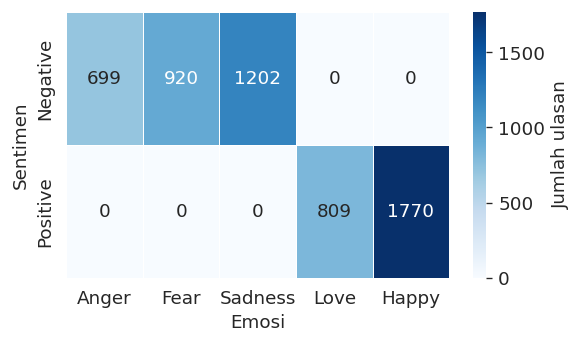

In [6]:
ct = pd.crosstab(df['Emotion'], df['Sentiment'])
ct = ct.reindex(EMO_ORDER).T

fig, ax = plt.subplots(figsize=(5, 3))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
            cbar_kws={'label': 'Jumlah ulasan'}, ax=ax)
ax.set_xlabel('Emosi')
ax.set_ylabel('Sentimen')
plt.tight_layout()
plt.show()

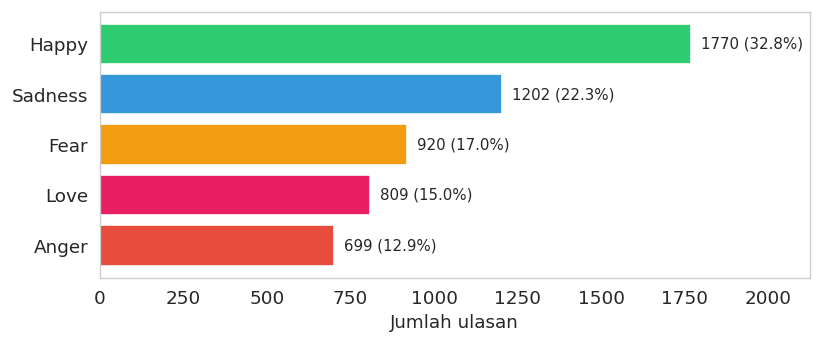

In [7]:
emo_counts = df['Emotion'].value_counts().reindex(EMO_ORDER)
emo_counts = emo_counts.sort_values(ascending=True) 

colors = [EMO_COLORS[e] for e in emo_counts.index]

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(emo_counts.index, emo_counts.values, color=colors, edgecolor='white')
total = emo_counts.sum()
for bar, val in zip(bars, emo_counts.values):
    pct = val / total * 100
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
            f'{val} ({pct:.1f}%)', va='center', fontsize=9)
ax.set_xlabel('Jumlah ulasan')
ax.margins(x=0.2)

ax.grid(False)

plt.tight_layout()
plt.show()

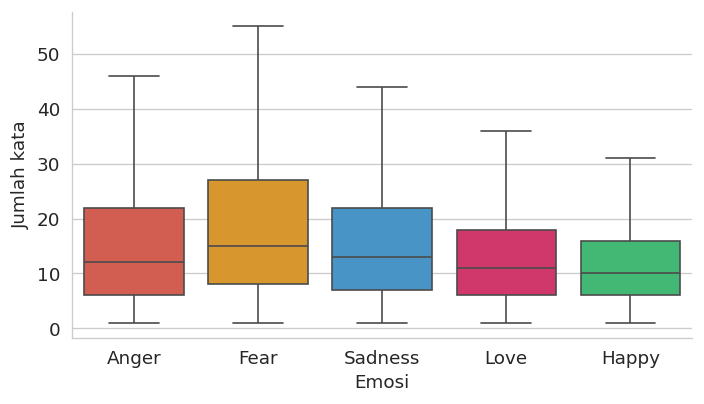

Median word count per emotion:
Emotion
Anger      12.0
Fear       15.0
Sadness    13.0
Love       11.0
Happy      10.0
Name: word_count, dtype: float64


In [8]:
df['word_count'] = df['Customer Review'].fillna('').apply(lambda x: len(x.split()))

fig, ax = plt.subplots(figsize=(6, 3.5))
palette = [EMO_COLORS[e] for e in EMO_ORDER]
sns.boxplot(data=df, x='Emotion', y='word_count', order=EMO_ORDER,
            palette=palette, ax=ax, showfliers=False)
ax.set_xlabel('Emosi')
ax.set_ylabel('Jumlah kata')
sns.despine()
plt.tight_layout()
plt.show()

print("Median word count per emotion:")
print(df.groupby('Emotion')['word_count'].median().reindex(EMO_ORDER).round(1))

# 4. Text Mining EDA

In [9]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.util import ngrams
from collections import Counter
from wordcloud import WordCloud

STOPWORDS_ID = set(stopwords.words('indonesian'))
df['tokens'] = df['Customer Review'].fillna('').apply(
    lambda x: word_tokenize(x.lower()))
print("Tokens computed.")

Tokens computed.


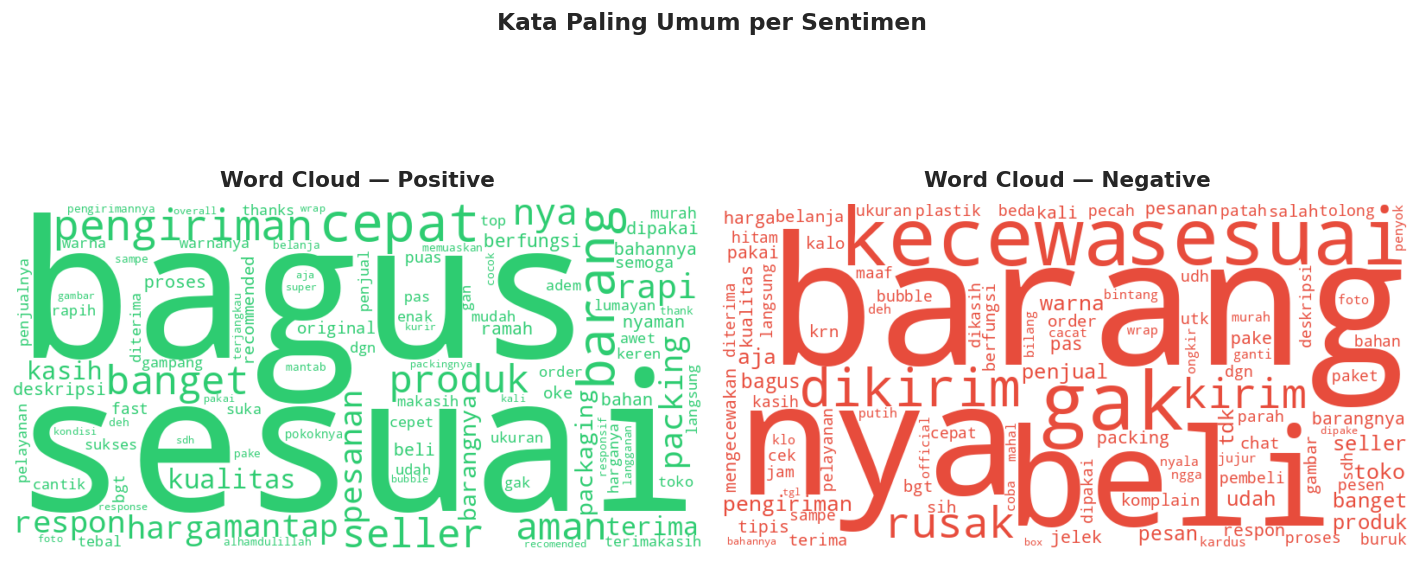

In [10]:
# WC — Word cloud per Sentimen
def green_color(word, font_size, position, orientation, random_state=None, **kwargs):
    return '#2ECC71'
def red_color(word, font_size, position, orientation, random_state=None, **kwargs):
    return '#E74C3C'

def get_word_freq(tokens_series):
    all_tokens = [t for tokens in tokens_series for t in tokens
                  if t not in STOPWORDS_ID and t.isalpha() and len(t) > 2]
    return dict(Counter(all_tokens))

pos_freq = get_word_freq(df[df['Sentiment'] == 'Positive']['tokens'])
neg_freq = get_word_freq(df[df['Sentiment'] == 'Negative']['tokens'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))

# Positive - solid hijau
wc_pos = WordCloud(width=800, height=400, background_color='white',
                   max_words=100, color_func=green_color,
                   random_state=RANDOM_STATE)
wc_pos.generate_from_frequencies(pos_freq)
ax1.imshow(wc_pos, interpolation='bilinear')
ax1.set_title('Word Cloud — Positive', weight='bold', fontsize=13, pad=10)
ax1.axis('off')

# Negative - solid merah
wc_neg = WordCloud(width=800, height=400, background_color='white',
                   max_words=100, color_func=red_color,
                   random_state=RANDOM_STATE)
wc_neg.generate_from_frequencies(neg_freq)
ax2.imshow(wc_neg, interpolation='bilinear')
ax2.set_title('Word Cloud — Negative', weight='bold', fontsize=13, pad=10)
ax2.axis('off')

plt.suptitle('Kata Paling Umum per Sentimen', weight='bold', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

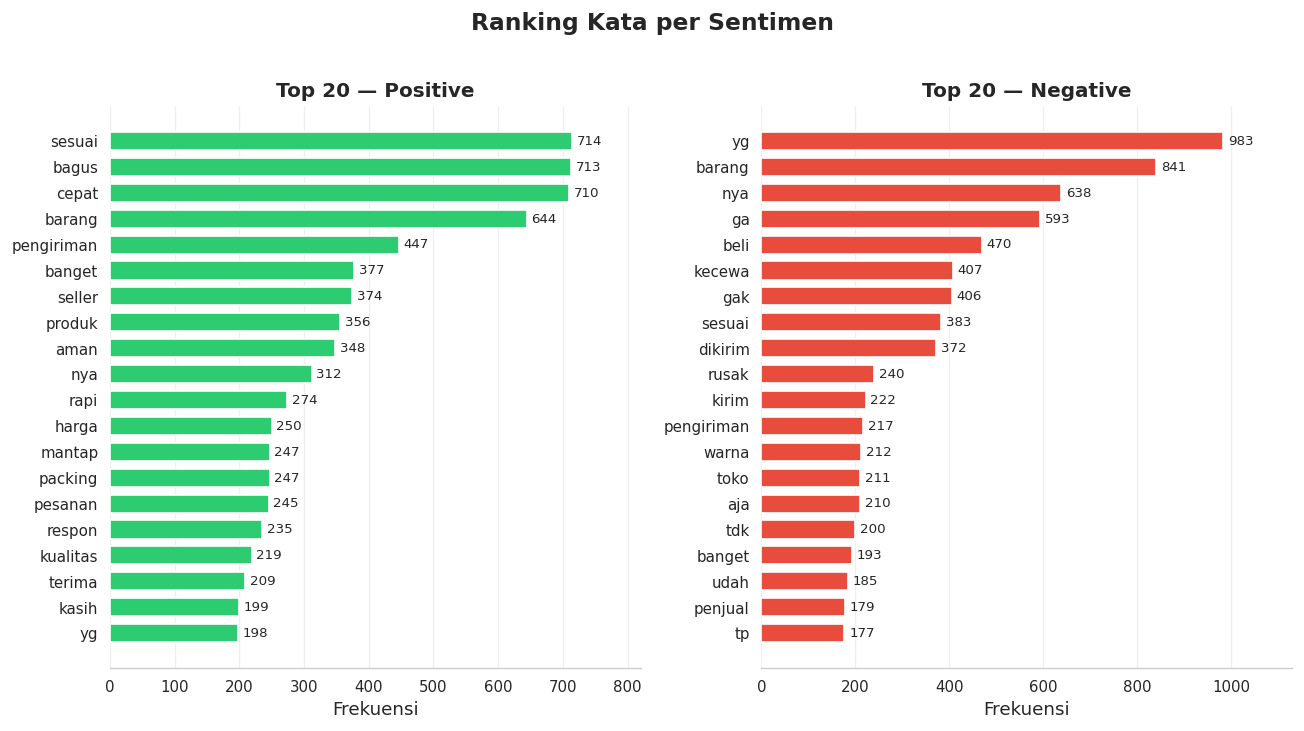

Kata overlap di Top 20 kedua sentimen: sesuai, barang, pengiriman, banget, nya, yg

Kata tidak baku (gak, bgus, ga) => justifikasi normalisasi slang.
Kata tidak di kedua sisi => justifikasi penanganan negasi.


In [11]:
# RC — Ranking bar chart Top 20 kata per Sentimen
def top_words(tokens_series, n=20):
    all_tokens = [t for tokens in tokens_series for t in tokens
                  if t not in STOPWORDS_ID and t.isalpha()]
    return Counter(all_tokens).most_common(n)

pos_w = top_words(df[df['Sentiment'] == 'Positive']['tokens'])
neg_w = top_words(df[df['Sentiment'] == 'Negative']['tokens'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 6))

for ax, words, title, c in zip(
    [ax1, ax2], [pos_w, neg_w],
    ['Positive', 'Negative'], ['#2ECC71', '#E74C3C']
):
    labels = [w[0] for w in words][::-1]
    vals = [w[1] for w in words][::-1]
    bars = ax.barh(labels, vals, color=c, edgecolor='white', height=0.7)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + max(vals)*0.01, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=8)
    ax.set_title(f'Top 20 — {title}', weight='bold', fontsize=12)
    ax.set_xlabel('Frekuensi')
    ax.margins(x=0.15)
    ax.tick_params(labelsize=9)
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.xaxis.grid(True, alpha=0.3)
    ax.yaxis.grid(False)

plt.suptitle('Ranking Kata per Sentimen', weight='bold', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

neg_set = set(w for w, _ in neg_w)
overlap = [w for w, _ in pos_w if w in neg_set]
overlap_str = ', '.join(overlap)
print(f'Kata overlap di Top 20 kedua sentimen: {overlap_str}')
print('\nKata tidak baku (gak, bgus, ga) => justifikasi normalisasi slang.')
print('Kata tidak di kedua sisi => justifikasi penanganan negasi.')